In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [3]:
from src.data.api_client import APIClientFactory
from src.data.data_validator import DataValidator

In [4]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns 

## Before Feature Engineering

In [5]:
client = APIClientFactory.get_primary_client()
validator = DataValidator()

In [6]:
historical_aqi = client.fetch_historical("Lahore", 31.558, 74.351, "2026-07-20", "2026-07-25")

2026-07-26 22:42:55 | INFO     | OpenMeteoClient:75 | Fetching historical data from https://air-quality-api.open-meteo.com/v1/air-quality for Lahore [2026-07-20 -> 2026-07-25]


In [7]:
type(historical_aqi)

list

In [8]:
df_aqi = pd.DataFrame(historical_aqi)

In [9]:
df_aqi.head()

,date,city,lat,lon,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,uv_index,aerosol_optical_depth,european_aqi
0,2026-07-20 00:00:00+05:00,Lahore,31.558,74.351,158.300003,91.699997,680.0,34.000000,11.6,45.0,0.0,1.05,113.241653
1,2026-07-20 01:00:00+05:00,Lahore,31.558,74.351,155.500000,92.699997,679.0,31.200001,11.3,46.0,0.0,1.08,113.093330
2,2026-07-20 02:00:00+05:00,Lahore,31.558,74.351,167.600006,97.800003,660.0,28.200001,11.2,48.0,0.0,1.08,113.000000
3,2026-07-20 03:00:00+05:00,Lahore,31.558,74.351,156.500000,94.300003,602.0,25.000000,11.7,51.0,0.0,1.03,113.348328
4,2026-07-20 04:00:00+05:00,Lahore,31.558,74.351,169.500000,93.400002,525.0,21.500000,12.6,55.0,0.0,1.04,113.689995


In [10]:
df_data = df_aqi.copy()

In [11]:
df_data.head()

,date,city,lat,lon,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,uv_index,aerosol_optical_depth,european_aqi
0,2026-07-20 00:00:00+05:00,Lahore,31.558,74.351,158.300003,91.699997,680.0,34.000000,11.6,45.0,0.0,1.05,113.241653
1,2026-07-20 01:00:00+05:00,Lahore,31.558,74.351,155.500000,92.699997,679.0,31.200001,11.3,46.0,0.0,1.08,113.093330
2,2026-07-20 02:00:00+05:00,Lahore,31.558,74.351,167.600006,97.800003,660.0,28.200001,11.2,48.0,0.0,1.08,113.000000
3,2026-07-20 03:00:00+05:00,Lahore,31.558,74.351,156.500000,94.300003,602.0,25.000000,11.7,51.0,0.0,1.03,113.348328
4,2026-07-20 04:00:00+05:00,Lahore,31.558,74.351,169.500000,93.400002,525.0,21.500000,12.6,55.0,0.0,1.04,113.689995


In [12]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype                       
---  ------                 --------------  -----                       
 0   date                   144 non-null    datetime64[ns, Asia/Karachi]
 1   city                   144 non-null    object                      
 2   lat                    144 non-null    float64                     
 3   lon                    144 non-null    float64                     
 4   pm10                   144 non-null    float64                     
 5   pm2_5                  144 non-null    float64                     
 6   carbon_monoxide        144 non-null    float64                     
 7   nitrogen_dioxide       144 non-null    float64                     
 8   sulphur_dioxide        144 non-null    float64                     
 9   ozone                  144 non-null    float64                     
 10  uv_index      

In [13]:
df_data.describe()

,lat,lon,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,uv_index,aerosol_optical_depth,european_aqi
count,144.000,144.000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000
mean,31.558,74.351,60.119445,39.950695,540.277778,21.786111,8.836111,84.430556,1.178472,0.932153,76.792057
std,0.000,0.000,63.254859,24.854891,182.040972,12.656564,2.612573,39.895432,1.818280,0.334591,21.784196
min,31.558,74.351,11.400000,9.300000,263.000000,3.900000,2.800000,19.000000,0.000000,0.470000,45.883339
25%,31.558,74.351,23.275000,21.975000,422.000000,13.200000,7.300000,55.000000,0.000000,0.660000,63.015831
50%,31.558,74.351,40.049999,33.000000,484.500000,19.500000,8.400000,73.000000,0.100000,0.865000,67.222118
75%,31.558,74.351,61.200000,47.550000,616.000000,28.050000,9.825000,115.000000,1.762500,1.110000,87.312080
max,31.558,74.351,323.200012,119.000000,1186.000000,70.400002,17.500000,182.000000,7.400000,2.230000,122.641678


In [16]:
df = df_data.loc[:, "pm10":]

In [17]:
corr = df.corr()
corr.style.background_gradient(cmap='coolwarm')

,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,uv_index,aerosol_optical_depth,european_aqi
pm10,1.000000,0.927117,0.045810,-0.015673,0.756576,0.223462,-0.079745,0.586289,0.818928
pm2_5,0.927117,1.000000,0.259306,0.254984,0.756263,0.062834,-0.229284,0.627227,0.733383
carbon_monoxide,0.045810,0.259306,1.000000,0.779437,0.199630,-0.382488,-0.361270,-0.029115,-0.127875
nitrogen_dioxide,-0.015673,0.254984,0.779437,1.000000,0.135634,-0.708327,-0.553377,0.054379,-0.130768
sulphur_dioxide,0.756576,0.756263,0.199630,0.135634,1.000000,0.157389,0.150804,0.335751,0.576131
ozone,0.223462,0.062834,-0.382488,-0.708327,0.157389,1.000000,0.608692,0.190667,0.185806
uv_index,-0.079745,-0.229284,-0.361270,-0.553377,0.150804,0.608692,1.000000,-0.246974,-0.084979
aerosol_optical_depth,0.586289,0.627227,-0.029115,0.054379,0.335751,0.190667,-0.246974,1.000000,0.498125
european_aqi,0.818928,0.733383,-0.127875,-0.130768,0.576131,0.185806,-0.084979,0.498125,1.000000


<Axes: >

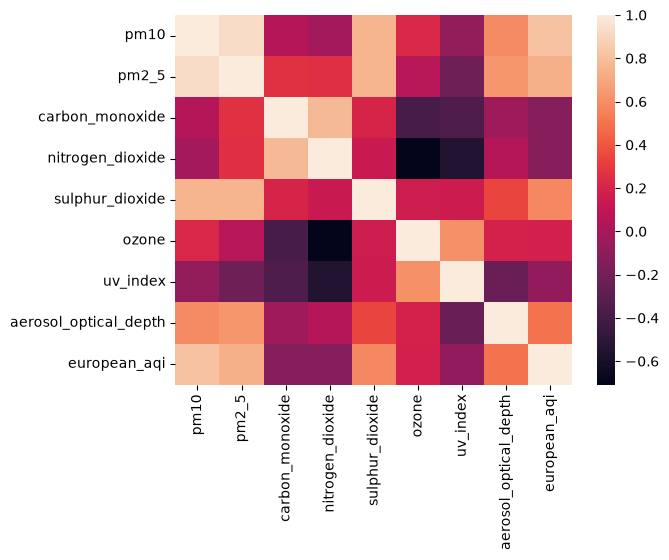

In [18]:
sns.heatmap(corr)